In [1]:
import warnings
warnings.filterwarnings("ignore")
 
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.cm as cm
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import os

In [2]:
#Add for Visuals
PALETTE   = "viridis"
ACCENT    = "#2563EB"
HIGHLIGHT = "#DC2626"
NEUTRAL   = "#64748B"
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 150, "savefig.bbox": "tight",
                     "savefig.facecolor": "white"})

In [3]:
#Read the data
#The data source is from the BEA for 2022-2025
raw = pd.read_csv("GDPDollarByState.csv")
raw["Description"] = raw["Description"].str.strip()
print(f"Raw shape: {raw.shape}")

Raw shape: (1406, 20)


In [4]:
raw.head(5)

,GeoFIPS,GeoName,LineCode,Description,2022:Q1,2022:Q2,2022:Q3,2022:Q4,2023:Q1,2023:Q2,2023:Q3,2023:Q4,2024:Q1,2024:Q2,2024:Q3,2024:Q4,2025:Q1,2025:Q2,2025:Q3,2025:Q4
0,0,United States *,1,All industry total,25250347.0,25861292.0,26336304.0,26770514.0,27216445.0,27530055.0,28074846.0,28424722.0,28708161.0,29147044.0,29511664.0,29825182.0,30042113.0,30485729.0,31098027.0,31422526.0
1,0,United States *,2,Private industries,22370435.0,22958308.0,23394534.0,23792288.0,24186841.0,24462441.0,24949510.0,25252382.0,25477141.0,25871320.0,26193383.0,26464842.0,26639914.0,27051641.0,27629228.0,27939572.0
2,0,United States *,3,"Agriculture, forestry, fishing and hunting",271638.0,296635.0,300780.0,307138.0,302022.0,276696.0,261042.0,242003.0,256803.0,261204.0,268639.0,292099.0,293163.0,266907.0,265971.0,262013.0
3,0,United States *,6,"Mining, quarrying, and oil and gas extraction",420912.0,513633.0,496340.0,436892.0,403631.0,386371.0,424049.0,433225.0,406190.0,418263.0,403323.0,389216.0,411077.0,376031.0,379094.0,370940.0
4,0,United States *,10,Utilities,391678.0,452398.0,464923.0,454149.0,460092.0,463011.0,464068.0,443915.0,452495.0,459787.0,450744.0,454405.0,460146.0,460838.0,478277.0,485724.0


In [5]:
Q_COLS = [c for c in raw.columns if ":" in c]
print(f"Quarters: {Q_COLS}")

Quarters: ['2022:Q1', '2022:Q2', '2022:Q3', '2022:Q4', '2023:Q1', '2023:Q2', '2023:Q3', '2023:Q4', '2024:Q1', '2024:Q2', '2024:Q3', '2024:Q4', '2025:Q1', '2025:Q2', '2025:Q3', '2025:Q4']


In [6]:
# Convert quarter values to numeric (they may contain commas or spaces)
for q in Q_COLS:
    raw[q] = pd.to_numeric(raw[q].astype(str).str.replace(",", ""), errors="coerce")

In [7]:
# Build long-format DataFrame
long = raw.melt(id_vars=["GeoFIPS", "GeoName", "LineCode", "Description"],
                value_vars=Q_COLS, var_name="Quarter", value_name="GDP_M")

In [8]:
# Create a function for reason: Parse quarter -> period index
def qstr_to_period(s):
    yr, q = s.split(":")
    month = {"Q1": 1, "Q2": 4, "Q3": 7, "Q4": 10}[q]
    return pd.Period(f"{yr}Q{q[1]}")

In [9]:
long["Period"] = long["Quarter"].apply(qstr_to_period)
long["Year"] = long["Period"].apply(lambda p: p.year)
long["Qtr"] = long["Period"].apply(lambda p: p.quarter)
long["GDP_B"] = long["GDP_M"] / 1_000          # millions -> billions
long["GDP_T"] = long["GDP_M"] / 1_000_000      # millions -> trillions
long = long.sort_values(["GeoName", "Description", "Period"])

In [10]:
#Subset: only US-level "All industry total" → national GDP time series
us_total = long[(long["GeoName"] == "United States *") &
                (long["Description"] == "All industry total")].copy()
 
# State-level "All industry total" (excluding US total and overseas)
state_total = long[(long["GeoName"] != "United States *") &
                   (~long["GeoName"].str.contains("overseas", case=False)) &
                   (long["Description"] == "All industry total")].copy()
 
# Industry breakdown at US level
us_industry = long[(long["GeoName"] == "United States *") &
                   (~long["Description"].str.contains("overseas", case=False))].copy()

In [11]:
# Compute QoQ growth for states
state_total["QoQ_Growth"] = (
    state_total.sort_values("Period")
               .groupby("GeoName")["GDP_M"]
               .pct_change() * 100
)

In [12]:
print(f"\nUS total quarters: {len(us_total)}")
print(f"State rows: {len(state_total)}")
print(f"Industry rows (US): {len(us_industry)}")
print(f"\nGDP Range (US All-industry): "
      f"${us_total['GDP_T'].min():.2f}T – ${us_total['GDP_T'].max():.2f}T")
 


US total quarters: 16
State rows: 816
Industry rows (US): 432

GDP Range (US All-industry): $25.25T – $31.42T


In [13]:
state_pivot = state_total.pivot_table(
    index="GeoName", columns="Quarter", values="GDP_M")
 
print(f"\nState pivot shape: {state_pivot.shape}")


State pivot shape: (51, 16)


In [14]:
%matplotlib inline

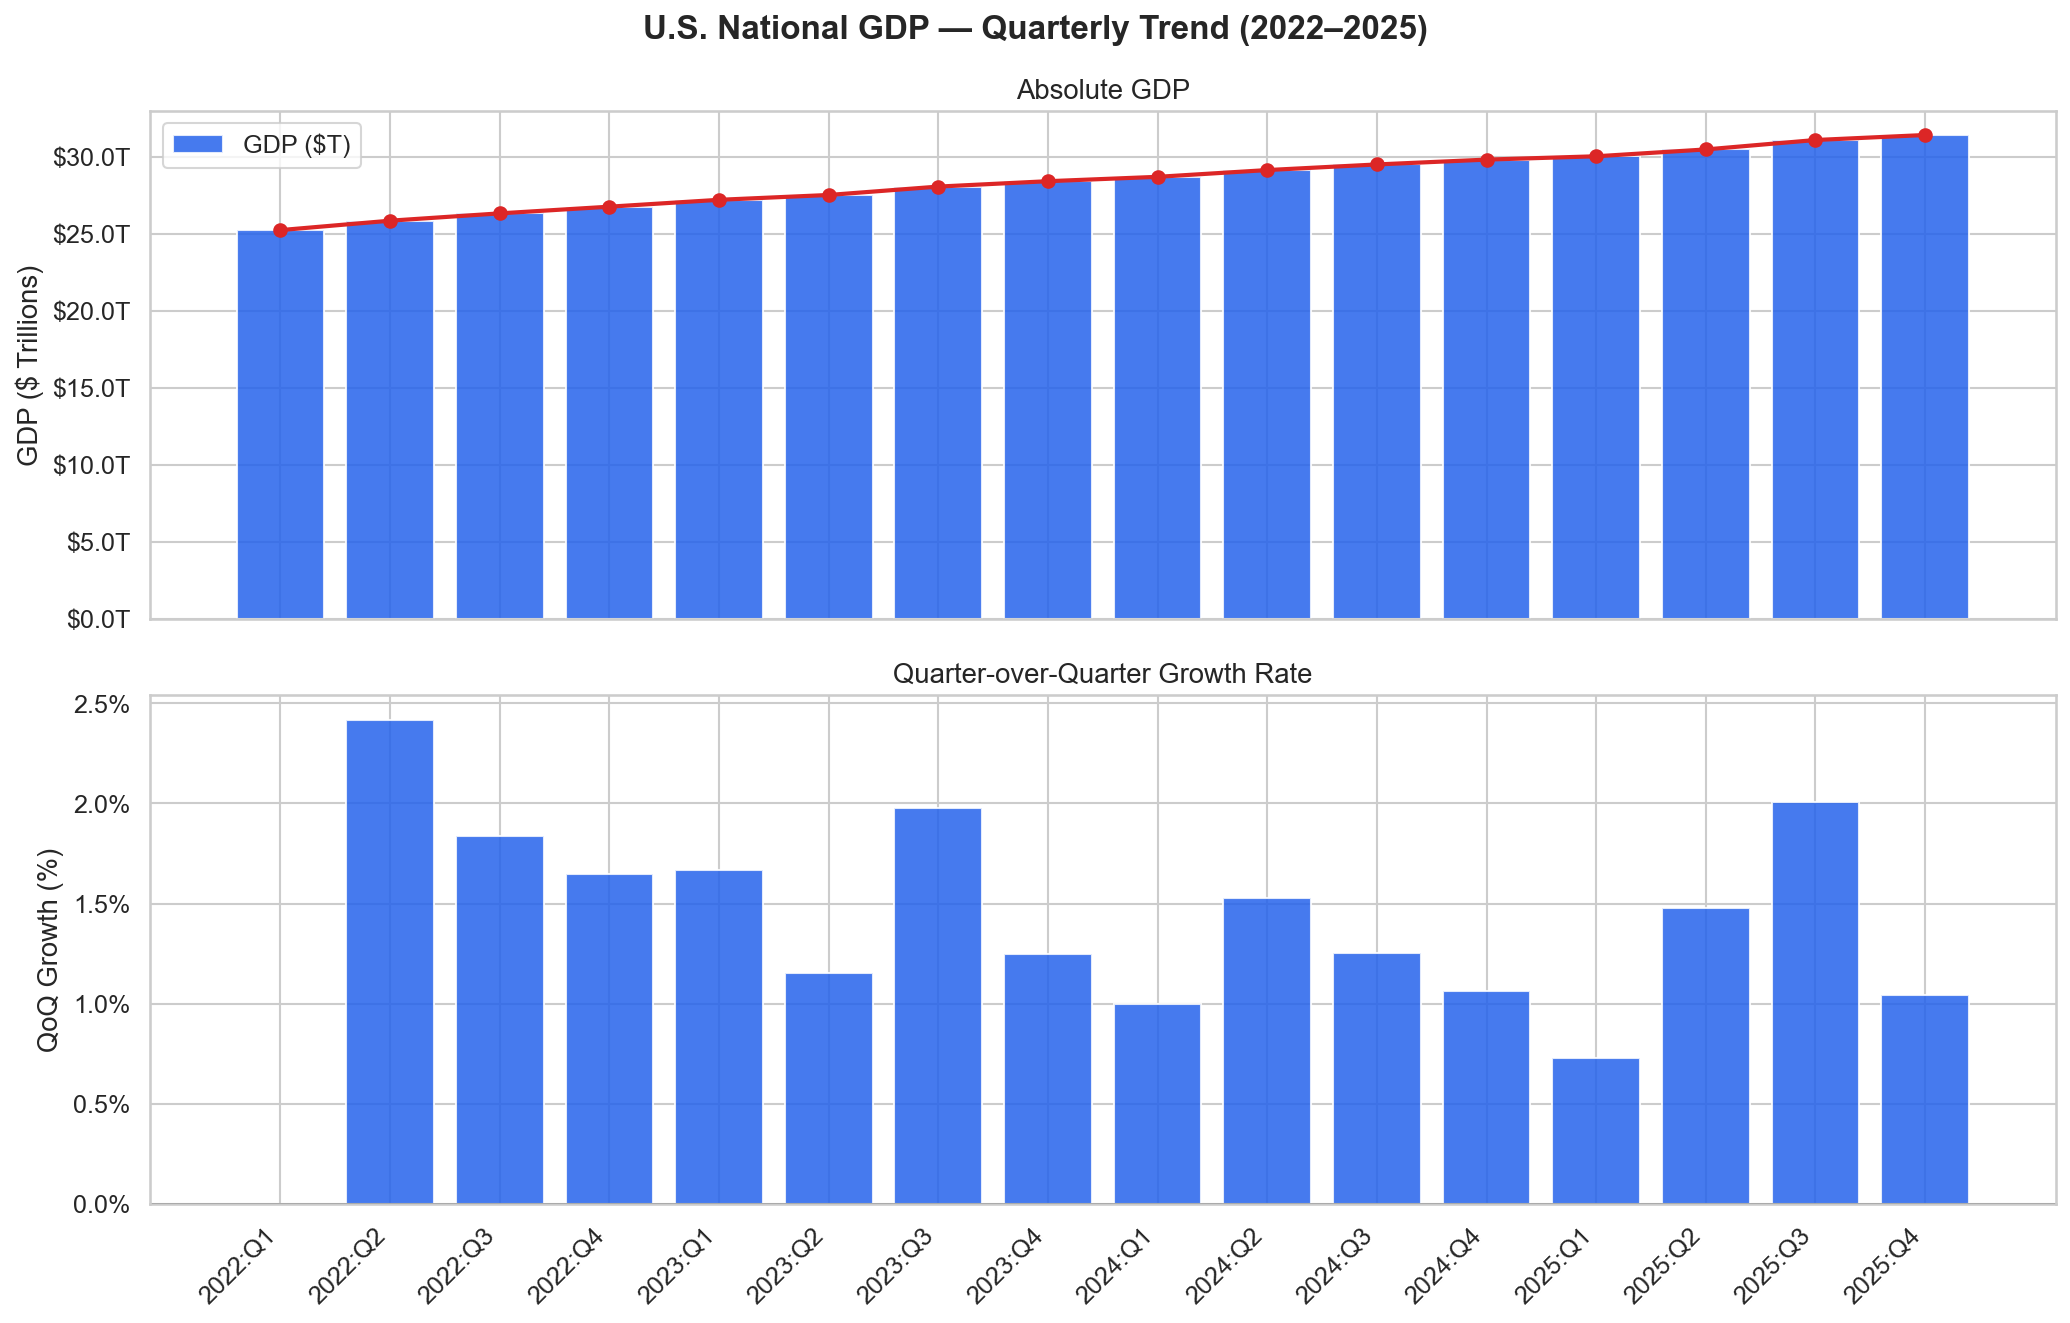

In [15]:
# ── 1-A  US National GDP Time Series ──────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle("U.S. National GDP — Quarterly Trend (2022–2025)", fontsize=16, fontweight="bold")
 
xs = list(range(len(us_total)))
xs_labels = us_total["Quarter"].tolist()
 
axes[0].bar(xs, us_total["GDP_T"], color=ACCENT, alpha=0.85, label="GDP ($T)")
axes[0].plot(xs, us_total["GDP_T"], color=HIGHLIGHT, marker="o", linewidth=2)
axes[0].set_ylabel("GDP ($ Trillions)")
axes[0].set_title("Absolute GDP")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:.1f}T"))
axes[0].legend()
 
qoq = us_total["GDP_T"].pct_change() * 100
colors = [ACCENT if v >= 0 else HIGHLIGHT for v in qoq.fillna(0)]
axes[1].bar(xs, qoq, color=colors, alpha=0.85)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("QoQ Growth (%)")
axes[1].set_title("Quarter-over-Quarter Growth Rate")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.1f}%"))
axes[1].set_xticks(xs)
axes[1].set_xticklabels(xs_labels, rotation=45, ha="right")
 
plt.tight_layout()
plt.show()

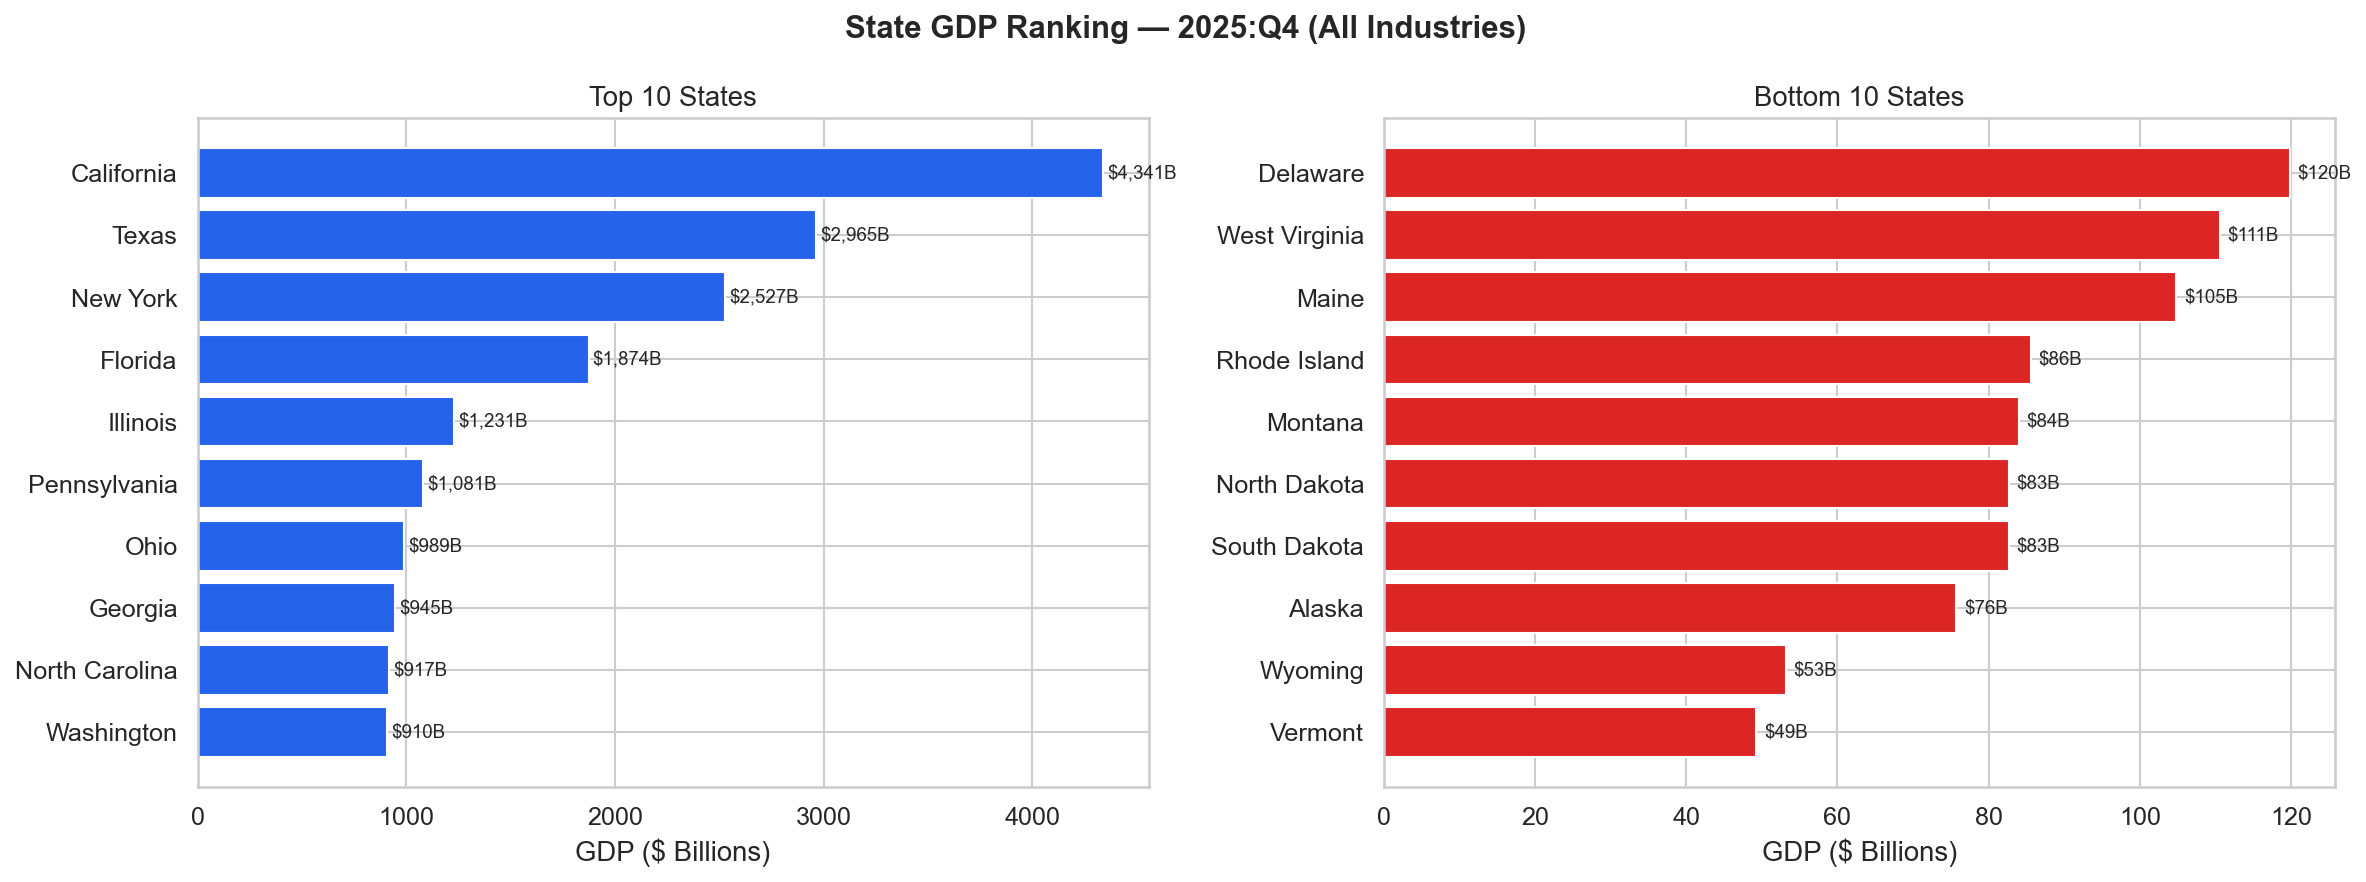

In [16]:
# ── 1-B  Top-10 States by Latest Quarter GDP ──────────────────────────────
latest_q = Q_COLS[-1]
state_latest = state_total[state_total["Quarter"] == latest_q].sort_values("GDP_B", ascending=False)
top10 = state_latest.head(10)
bot10 = state_latest.tail(10)
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"State GDP Ranking — {latest_q} (All Industries)", fontsize=15, fontweight="bold")
 
bars = axes[0].barh(top10["GeoName"][::-1], top10["GDP_B"][::-1], color=ACCENT)
axes[0].set_xlabel("GDP ($ Billions)")
axes[0].set_title("Top 10 States")
for bar, val in zip(bars, top10["GDP_B"][::-1]):
    axes[0].text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                 f"${val:,.0f}B", va="center", fontsize=9)
bars2 = axes[1].barh(bot10["GeoName"][::-1], bot10["GDP_B"][::-1], color=HIGHLIGHT)
axes[1].set_xlabel("GDP ($ Billions)")
axes[1].set_title("Bottom 10 States")
for bar, val in zip(bars2, bot10["GDP_B"][::-1]):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f"${val:,.0f}B", va="center", fontsize=9)
plt.tight_layout()
plt.show()

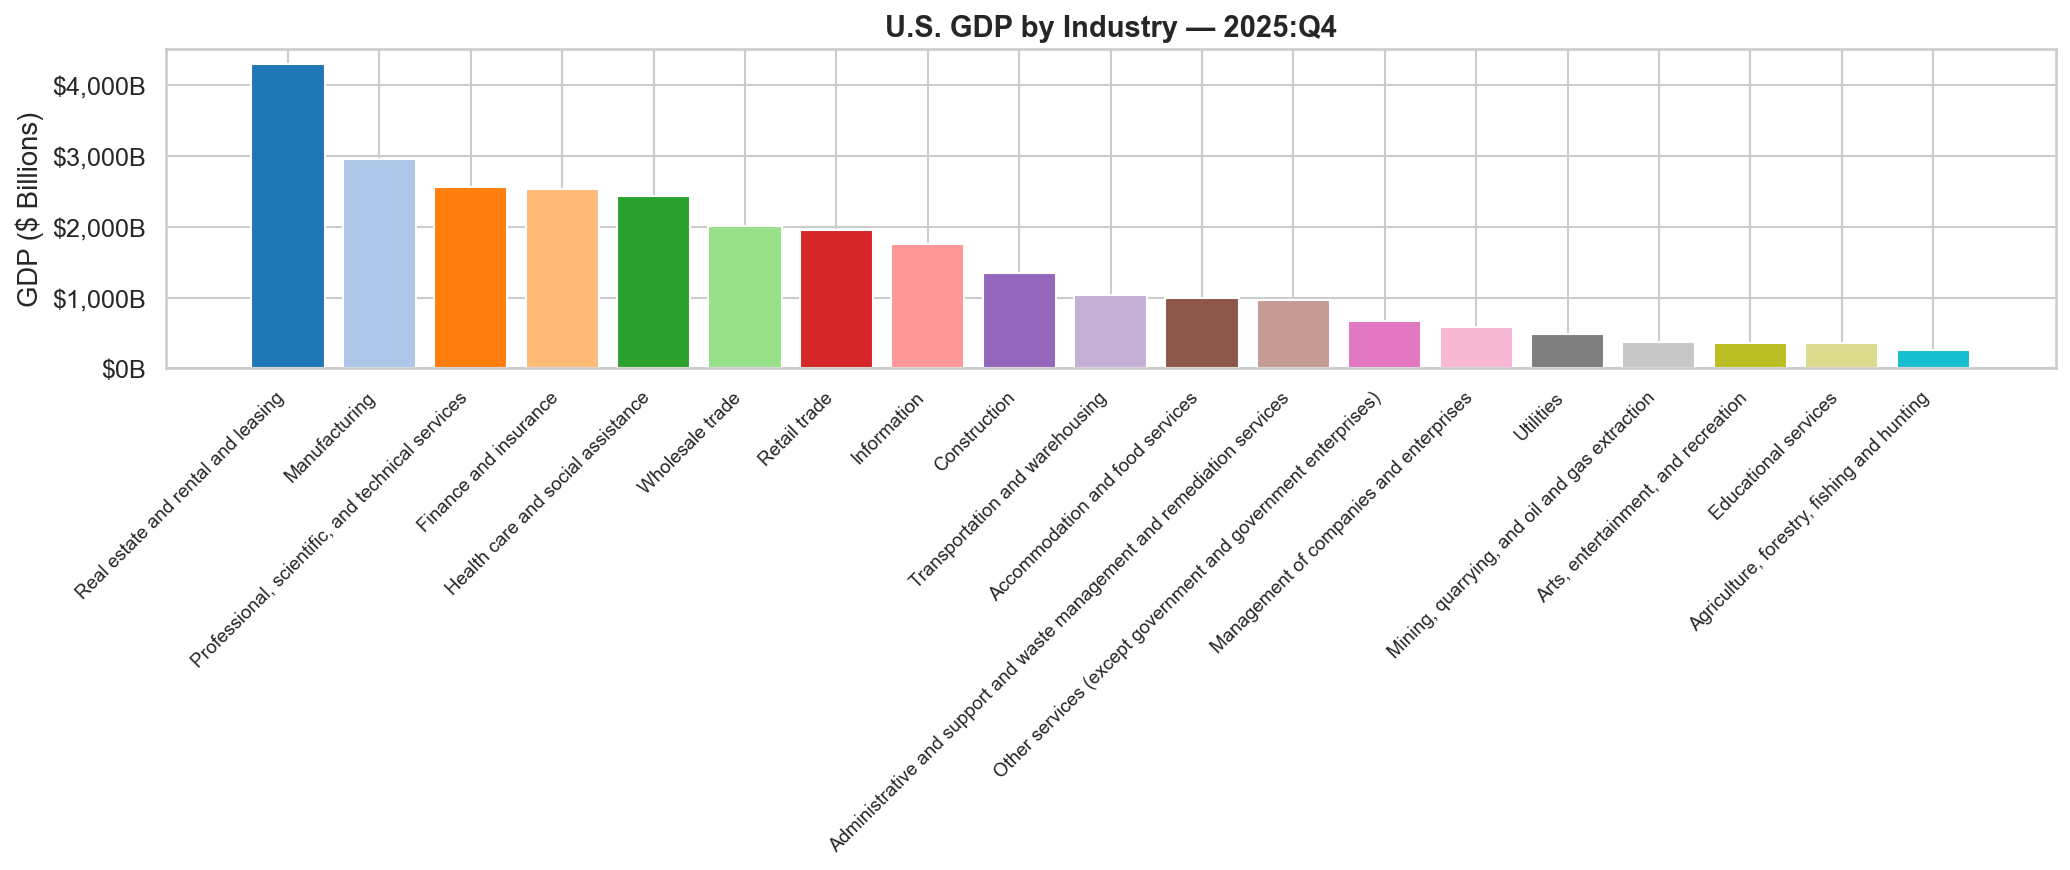

In [17]:
# ── 1-C  Industry Composition (US, Latest Quarter) ────────────────────────
industry_excl = [
    "All industry total", "Private industries",
    "Government and government enterprises",
    "All industry total, overseas activity",
    "Government and government enterprises, overseas activity",
    "Durable goods manufacturing", "Nondurable goods manufacturing",
    "Federal civilian", "Military", "State and local"
]
us_ind_latest = us_industry[
    (us_industry["Quarter"] == latest_q) &
    (~us_industry["Description"].isin(industry_excl))
].copy()
us_ind_latest = us_ind_latest.sort_values("GDP_B", ascending=False)
 
fig, ax = plt.subplots(figsize=(14, 6))
colors_pie = plt.cm.tab20.colors[:len(us_ind_latest)]
bars = ax.bar(range(len(us_ind_latest)), us_ind_latest["GDP_B"], color=colors_pie)
ax.set_xticks(range(len(us_ind_latest)))
ax.set_xticklabels([d.replace("      ", "").replace("  ", "") 
                    for d in us_ind_latest["Description"]],
                   rotation=45, ha="right", fontsize=9)
ax.set_ylabel("GDP ($ Billions)")
ax.set_title(f"U.S. GDP by Industry — {latest_q}", fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}B"))
plt.tight_layout()
plt.show()

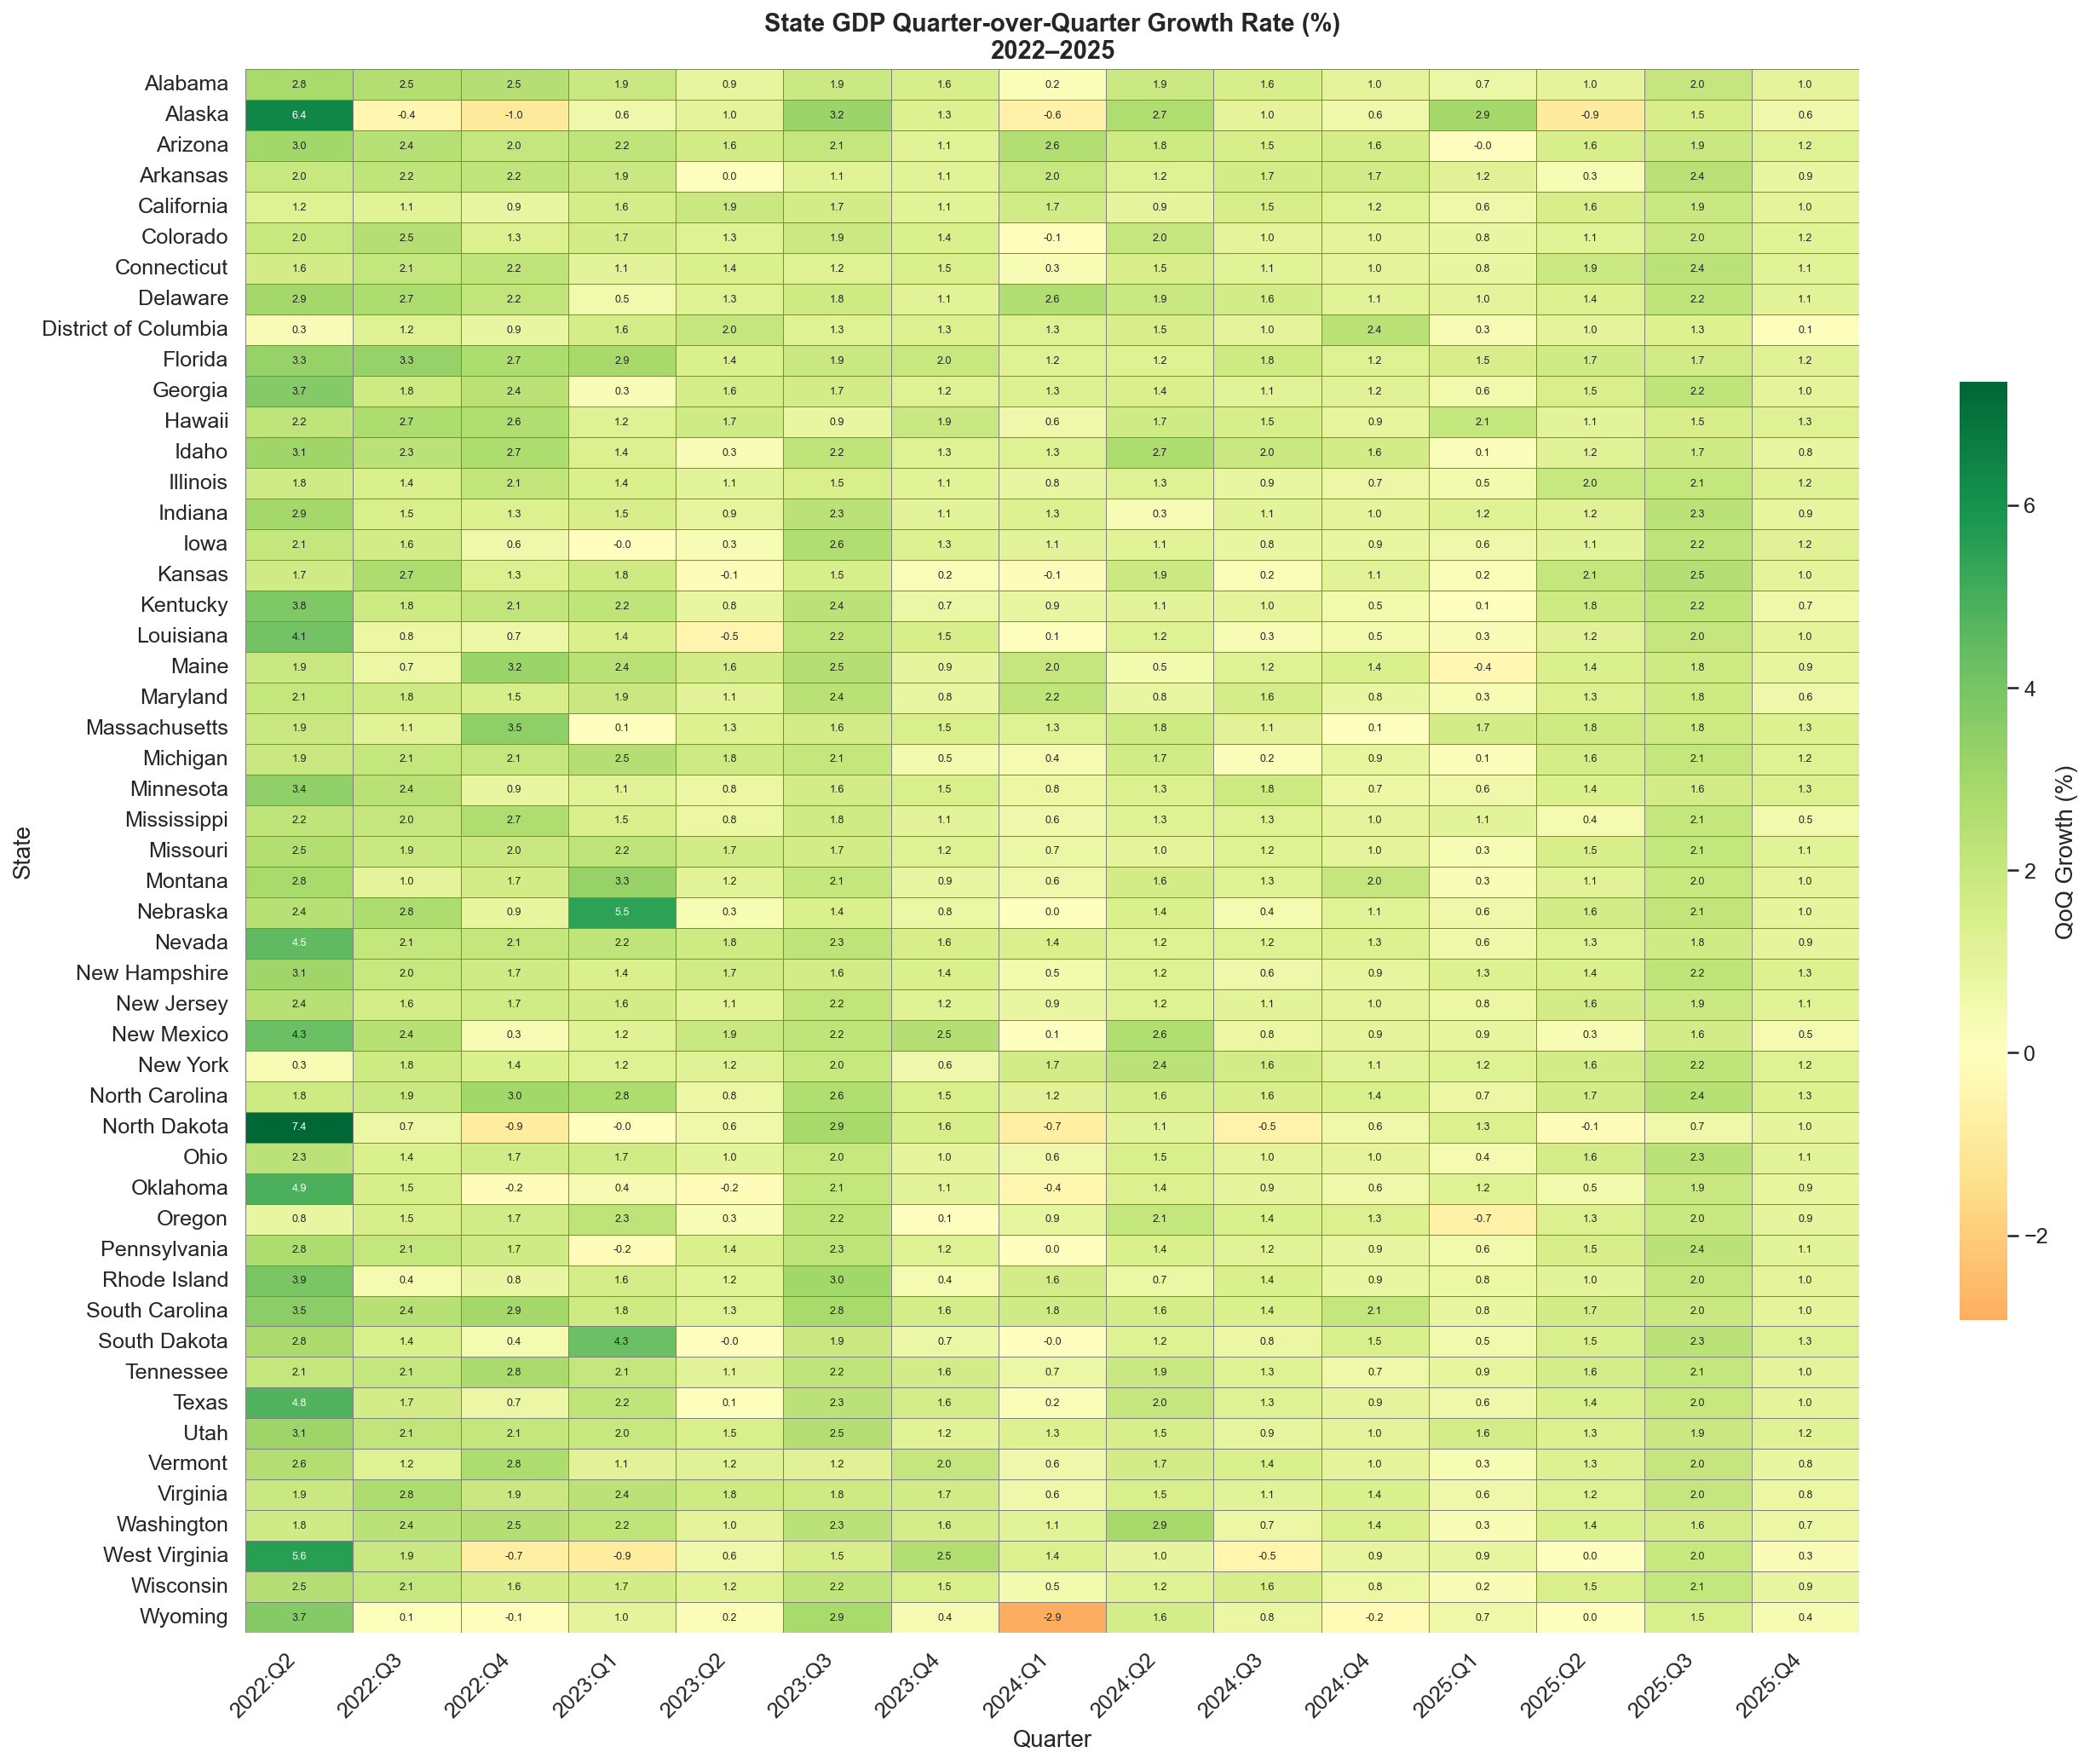

In [18]:
# ── 1-D  State GDP Growth Heatmap ─────────────────────────────────────────
state_qoq_pivot = state_total.pivot_table(
    index="GeoName", columns="Quarter", values="QoQ_Growth")
state_qoq_pivot = state_qoq_pivot.dropna(how="all")
 
fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(state_qoq_pivot, ax=ax, cmap="RdYlGn", center=0,
            linewidths=0.3, linecolor="gray",
            cbar_kws={"label": "QoQ Growth (%)", "shrink": 0.6},
            fmt=".1f", annot=True, annot_kws={"size": 6})
ax.set_title("State GDP Quarter-over-Quarter Growth Rate (%)\n2022–2025",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Quarter")
ax.set_ylabel("State")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

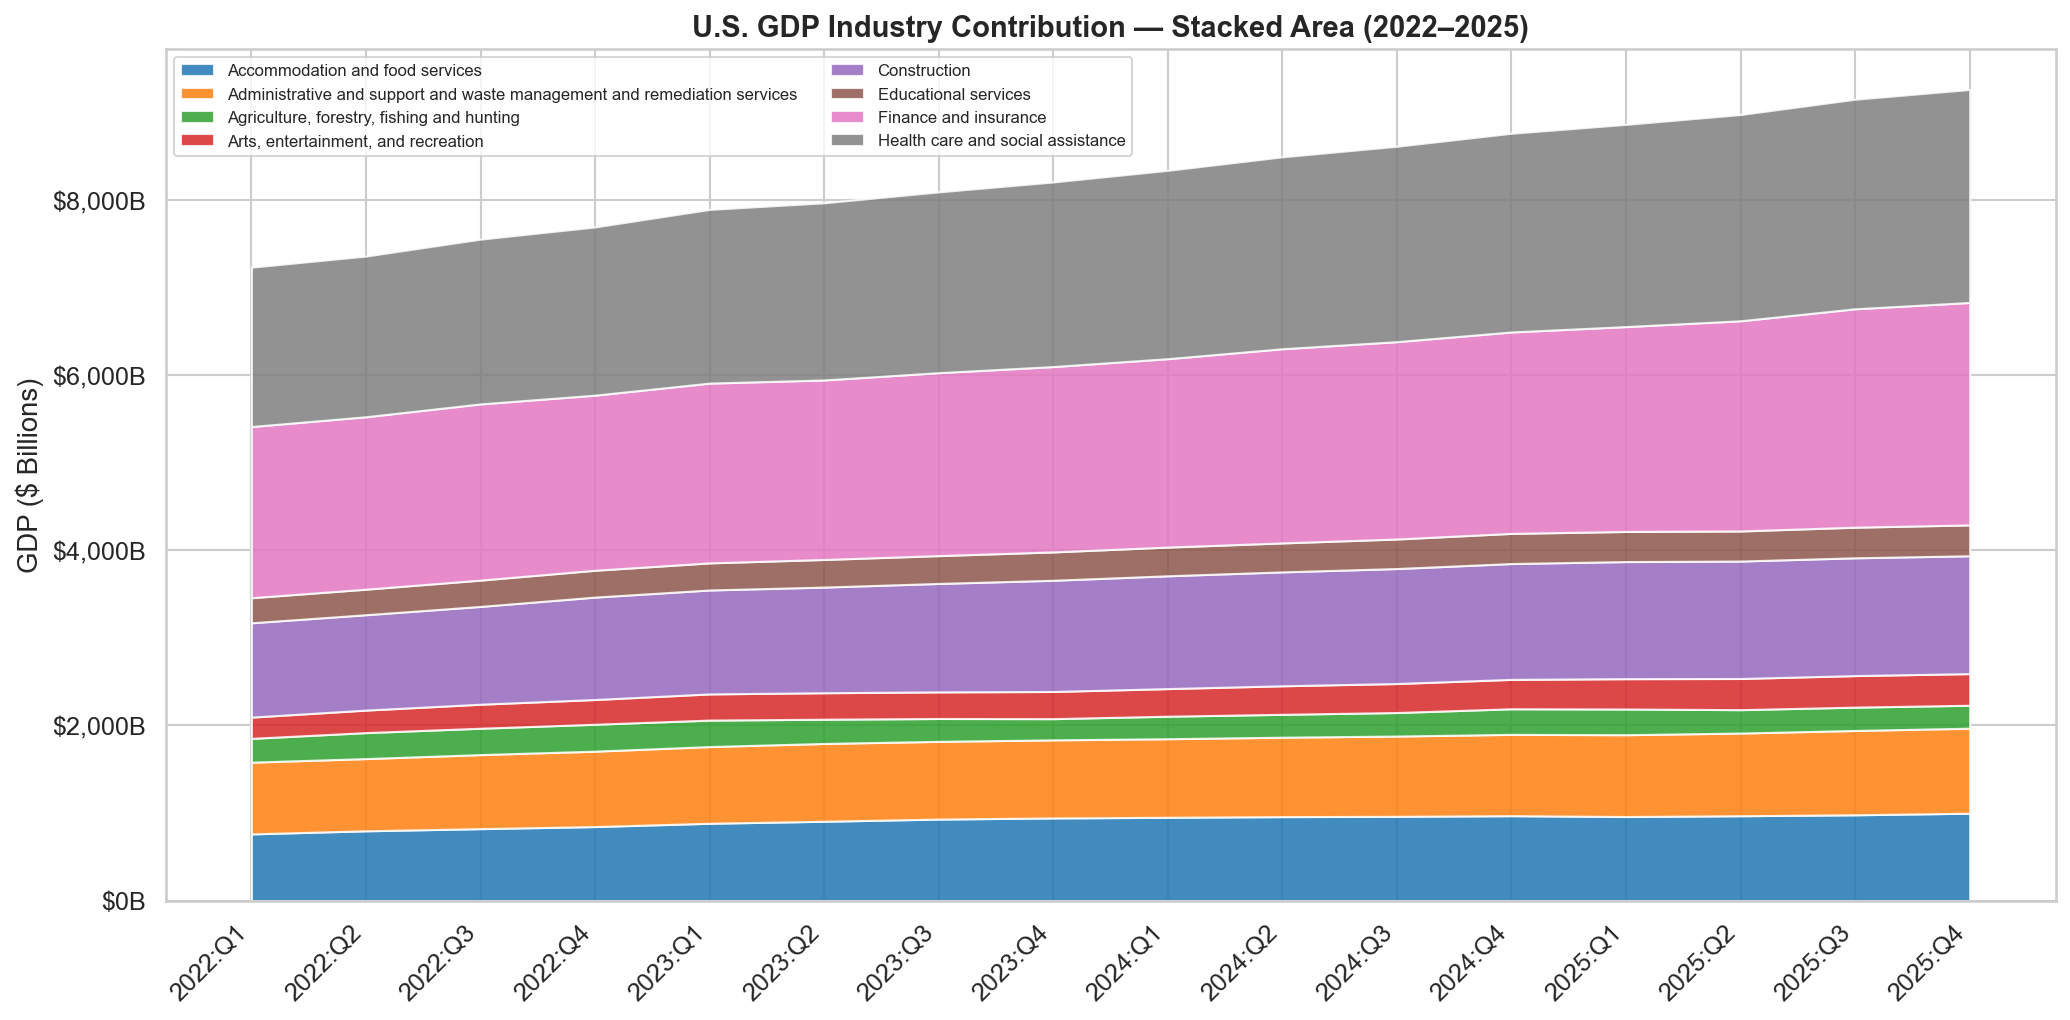

In [19]:
# ── 1-E  Industry Contribution Over Time (Stacked Area) ───────────────────
top_industries = [d for d in us_industry["Description"].unique()
                  if d not in industry_excl][:8]
ind_ts = us_industry[us_industry["Description"].isin(top_industries)].pivot_table(
    index="Quarter", columns="Description", values="GDP_B")
ind_ts.index = pd.CategoricalIndex(ind_ts.index, categories=Q_COLS, ordered=True)
ind_ts = ind_ts.sort_index()
ind_ts.columns = [c.strip() for c in ind_ts.columns]
 
fig, ax = plt.subplots(figsize=(14, 7))
colors_area = plt.cm.tab10.colors[:len(ind_ts.columns)]
ax.stackplot(range(len(ind_ts)), ind_ts.T.values,
             labels=ind_ts.columns, colors=colors_area, alpha=0.85)
ax.set_xticks(range(len(ind_ts)))
ax.set_xticklabels(Q_COLS, rotation=45, ha="right")
ax.set_ylabel("GDP ($ Billions)")
ax.set_title("U.S. GDP Industry Contribution — Stacked Area (2022–2025)",
             fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}B"))
ax.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

Hypothesis Testing

In [21]:
results_ht = []

# ── 2-A  Test 1: Did US GDP grow significantly from 2022 to 2025? ─────────
gdp_2022 = us_total[us_total["Year"] == 2022]["GDP_M"].values
gdp_2025 = us_total[us_total["Year"] == 2025]["GDP_M"].values
 
t_stat, p_val = stats.ttest_ind(gdp_2025, gdp_2022)
print(f"\n[TEST 1] Independent t-test: US GDP 2022 vs 2025")
print(f"  H0: Mean GDP in 2025 = Mean GDP in 2022")
print(f"  H1: Mean GDP in 2025 > Mean GDP in 2022 (one-tailed)")
print(f"  2022 mean: ${np.mean(gdp_2022)/1e6:.3f}T  |  2025 mean: ${np.mean(gdp_2025)/1e6:.3f}T")
print(f"  t-statistic: {t_stat:.4f}  |  p-value (two-tailed): {p_val:.6f}")
print(f"  p-value (one-tailed): {p_val/2:.6f}")
conclusion = "REJECT H0 — GDP significantly higher in 2025" if p_val/2 < 0.05 else "FAIL TO REJECT H0"
print(f"  Conclusion (α=0.05): {conclusion}")
results_ht.append({"Test": "t-test: 2022 vs 2025 GDP", "Statistic": t_stat,
                   "p-value": p_val/2, "Conclusion": conclusion})


[TEST 1] Independent t-test: US GDP 2022 vs 2025
  H0: Mean GDP in 2025 = Mean GDP in 2022
  H1: Mean GDP in 2025 > Mean GDP in 2022 (one-tailed)
  2022 mean: $26.055T  |  2025 mean: $30.762T
  t-statistic: 10.4830  |  p-value (two-tailed): 0.000044
  p-value (one-tailed): 0.000022
  Conclusion (α=0.05): REJECT H0 — GDP significantly higher in 2025


In [22]:
# ── Test 2: Paired t-test (Q1 vs Q3 seasonality) ────────────────────
q1_vals = state_total[state_total["Qtr"] == 1]["GDP_M"].values
q3_vals = state_total[state_total["Qtr"] == 3]["GDP_M"].values
 
t2, p2 = stats.ttest_rel(q3_vals[:min(len(q1_vals),len(q3_vals))],
                          q1_vals[:min(len(q1_vals),len(q3_vals))])
print(f"\n[TEST 2] Paired t-test: Seasonal Effect Q1 vs Q3 (State GDP)")
print(f"  H0: No seasonal difference between Q1 and Q3")
print(f"  Q1 mean: ${np.mean(q1_vals)/1e6:.3f}T  |  Q3 mean: ${np.mean(q3_vals)/1e6:.3f}T")
print(f"  t-statistic: {t2:.4f}  |  p-value: {p2:.6f}")
c2 = "REJECT H0 — Significant seasonal difference Q1 vs Q3" if p2 < 0.05 else "FAIL TO REJECT H0"
print(f"  Conclusion (α=0.05): {c2}")
results_ht.append({"Test": "Paired t-test: Q1 vs Q3", "Statistic": t2, "p-value": p2, "Conclusion": c2})


[TEST 2] Paired t-test: Seasonal Effect Q1 vs Q3 (State GDP)
  H0: No seasonal difference between Q1 and Q3
  Q1 mean: $0.542T  |  Q3 mean: $0.561T
  t-statistic: 10.7819  |  p-value: 0.000000
  Conclusion (α=0.05): REJECT H0 — Significant seasonal difference Q1 vs Q3


In [23]:
# ── Test 3: One-Way ANOVA — GDP by Quarter (Seasonality) ────────────
groups_by_qtr = [state_total[state_total["Qtr"] == q]["GDP_M"].dropna().values
                 for q in [1, 2, 3, 4]]
f3, p3 = stats.f_oneway(*groups_by_qtr)
print(f"\n[TEST 3] One-Way ANOVA: GDP by Quarter (Q1/Q2/Q3/Q4)")
print(f"  H0: Mean GDP is equal across all four quarters")
print(f"  F-statistic: {f3:.4f}  |  p-value: {p3:.6f}")
c3 = "REJECT H0 — Significant difference across quarters" if p3 < 0.05 else "FAIL TO REJECT H0"
print(f"  Conclusion (α=0.05): {c3}")
results_ht.append({"Test": "One-Way ANOVA: GDP by Quarter", "Statistic": f3, "p-value": p3, "Conclusion": c3})


[TEST 3] One-Way ANOVA: GDP by Quarter (Q1/Q2/Q3/Q4)
  H0: Mean GDP is equal across all four quarters
  F-statistic: 0.0501  |  p-value: 0.985182
  Conclusion (α=0.05): FAIL TO REJECT H0


In [24]:
# ── Test 4: Kruskal-Wallis — Non-parametric ANOVA (top 5 states) ────
top5_states = state_latest.head(5)["GeoName"].tolist()
groups_states = [state_total[state_total["GeoName"] == s]["GDP_M"].dropna().values
                 for s in top5_states]
kw_stat, kw_p = stats.kruskal(*groups_states)
print(f"\n[TEST 4] Kruskal-Wallis H-test: GDP distribution among top-5 states")
print(f"  States: {top5_states}")
print(f"  H0: All states have the same GDP distribution")
print(f"  H-statistic: {kw_stat:.4f}  |  p-value: {kw_p:.6f}")
c4 = "REJECT H0 — States differ significantly in GDP" if kw_p < 0.05 else "FAIL TO REJECT H0"
print(f"  Conclusion (α=0.05): {c4}")
results_ht.append({"Test": "Kruskal-Wallis: Top-5 States", "Statistic": kw_stat, "p-value": kw_p, "Conclusion": c4})


[TEST 4] Kruskal-Wallis H-test: GDP distribution among top-5 states
  States: ['California', 'Texas', 'New York', 'Florida', 'Illinois']
  H0: All states have the same GDP distribution
  H-statistic: 75.3926  |  p-value: 0.000000
  Conclusion (α=0.05): REJECT H0 — States differ significantly in GDP


In [25]:
# ── Test 5: Chi-Square — GDP Growth quartile vs quarter ──────────────
state_total2 = state_total.dropna(subset=["QoQ_Growth"]).copy()
state_total2["Growth_Cat"] = pd.qcut(state_total2["QoQ_Growth"], q=4,
                                      labels=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"])
contingency = pd.crosstab(state_total2["Qtr"], state_total2["Growth_Cat"])
chi2, chi_p, dof, _ = stats.chi2_contingency(contingency)
print(f"\n[TEST 5] Chi-Square Test: GDP Growth Category vs Fiscal Quarter")
print(f"  H0: GDP growth category is independent of fiscal quarter")
print(f"  Chi² = {chi2:.4f}  |  df = {dof}  |  p-value = {chi_p:.6f}")
c5 = "REJECT H0 — Growth category depends on quarter" if chi_p < 0.05 else "FAIL TO REJECT H0"
print(f"  Conclusion (α=0.05): {c5}")
results_ht.append({"Test": "Chi-Square: Growth Category × Quarter", "Statistic": chi2, "p-value": chi_p, "Conclusion": c5})


[TEST 5] Chi-Square Test: GDP Growth Category vs Fiscal Quarter
  H0: GDP growth category is independent of fiscal quarter
  Chi² = 143.6057  |  df = 9  |  p-value = 0.000000
  Conclusion (α=0.05): REJECT H0 — Growth category depends on quarter


In [26]:
# ── Post-hoc: Tukey HSD after ANOVA ─────────────────────────────────
print(f"\n[POST-HOC] Tukey HSD — Pairwise Quarter Comparisons")
tukey_data   = state_total[["GDP_M", "Qtr"]].dropna()
tukey_result = pairwise_tukeyhsd(tukey_data["GDP_M"], tukey_data["Qtr"], alpha=0.05)
print(tukey_result.summary())


[POST-HOC] Tukey HSD — Pairwise Quarter Comparisons
      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
group1 group2  meandiff  p-adj     lower        upper    reject
---------------------------------------------------------------
     1      2  8821.6176 0.9993 -172739.2846 190382.5199  False
     1      3  18563.427 0.9936 -162997.4753 200124.3292  False
     1      4 25506.5123 0.9838   -156054.39 207067.4145  False
     2      3  9741.8093 0.9991  -171819.093 191302.7116  False
     2      4 16684.8946 0.9953 -164876.0077 198245.7969  False
     3      4  6943.0853 0.9997  -174617.817 188503.9876  False
---------------------------------------------------------------


In [27]:
# ── ADF Stationarity Test on US GDP ──────────────────────────────────
print(f"\n[TEST 6] Augmented Dickey-Fuller: US National GDP Stationarity")
adf_result = adfuller(us_total["GDP_M"].dropna(), autolag="AIC")
print(f"  ADF Statistic: {adf_result[0]:.4f}")
print(f"  p-value:       {adf_result[1]:.4f}")
for k, v in adf_result[4].items():
    print(f"  Critical Value ({k}): {v:.4f}")
if adf_result[1] > 0.05:
    print("  → Series is NON-STATIONARY (unit root present) — differencing needed for ARIMA")
else:
    print("  → Series is STATIONARY")


[TEST 6] Augmented Dickey-Fuller: US National GDP Stationarity
  ADF Statistic: -0.9743
  p-value:       0.7625
  Critical Value (1%): -4.4731
  Critical Value (5%): -3.2899
  Critical Value (10%): -2.7724
  → Series is NON-STATIONARY (unit root present) — differencing needed for ARIMA


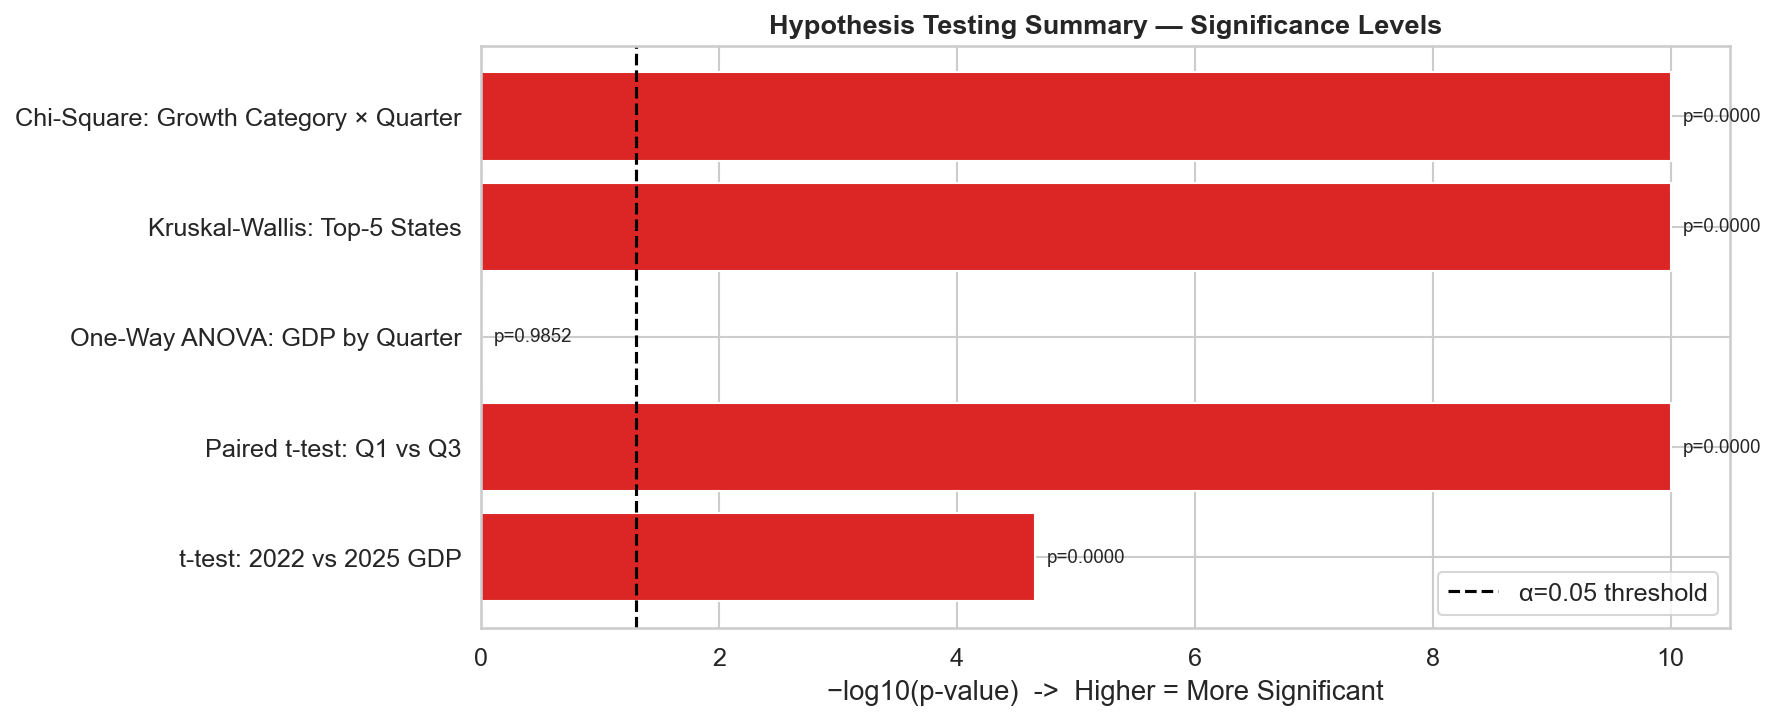

In [30]:
df_ht = pd.DataFrame(results_ht)
fig, ax = plt.subplots(figsize=(12, 5))
colors_ht = [HIGHLIGHT if p < 0.05 else NEUTRAL for p in df_ht["p-value"]]
bars = ax.barh(df_ht["Test"], -np.log10(df_ht["p-value"] + 1e-10), color=colors_ht)
ax.axvline(-np.log10(0.05), color="black", linestyle="--", linewidth=1.5, label="α=0.05 threshold")
ax.set_xlabel("−log10(p-value)  ->  Higher = More Significant")
ax.set_title("Hypothesis Testing Summary — Significance Levels", fontsize=13, fontweight="bold")
ax.legend()
for bar, row in zip(bars, df_ht.itertuples()):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"p={row._3:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()